## Problem Formulation
Financial fraud causes like significant losses for banks and different financial institutions. And the objective of this project is to build a machine learning model that can identify fraudulent transactions based on historical transaction data. The problem is formulated as a binary classification task, where:
- 0 represents a legitimate transaction
- 1 represents a fraudulent transaction

Accurate and early detection of fraudulent transactions is crucial to minimization of financial losses and protect customers

## Motivation

Fraud detection is a critical task in financial systems and incorrectly classifying fraudulent transactions as legitimate can lead like to direct financial losses, while false positives may negatively affect customer experience. So, it is important to build models that perform well on imbalanced data and focus on metrics beyond simple accuracy.

In [22]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [25]:
import kagglehub

path = kagglehub.dataset_download("samayashar/fraud-detection-transactions-dataset")

print("path to dataset", path)

Using Colab cache for faster access to the 'fraud-detection-transactions-dataset' dataset.
path to dataset /kaggle/input/fraud-detection-transactions-dataset


In [26]:
import pandas as pd

df = pd.read_csv('/kaggle/input/fraud-detection-transactions-dataset/synthetic_fraud_dataset.csv', nrows=10000)



# see size of dataset
print("number of rows and columns:", df.shape)

# first 5 rows
df.head()

#info about data and missings
df.info()


number of rows and columns: (10000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Transaction_ID                10000 non-null  object 
 1   User_ID                       10000 non-null  object 
 2   Transaction_Amount            10000 non-null  float64
 3   Transaction_Type              10000 non-null  object 
 4   Timestamp                     10000 non-null  object 
 5   Account_Balance               10000 non-null  float64
 6   Device_Type                   10000 non-null  object 
 7   Location                      10000 non-null  object 
 8   Merchant_Category             10000 non-null  object 
 9   IP_Address_Flag               10000 non-null  int64  
 10  Previous_Fraudulent_Activity  10000 non-null  int64  
 11  Daily_Transaction_Count       10000 non-null  int64  
 12  Avg_Transaction_Amoun

## Dataset description

The dataset contains transaction-level data, including information about transaction amounts, customer attributes, and transaction behavior. The target variable indicates whether a transaction is fraudulent. And the dataset is imbalanced, with significantly fewer fraudulent transactions compared to legitimate ones, which like reflects real-world financial data.

Fraud_Label
0    0.6771
1    0.3229
Name: proportion, dtype: float64


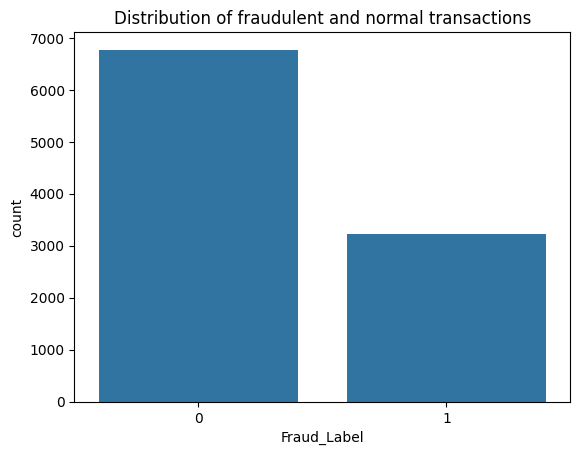

In [27]:

print(df['Fraud_Label'].value_counts(normalize=True))

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Fraud_Label', data=df)
plt.title("Distribution of fraudulent and normal transactions")
plt.show()




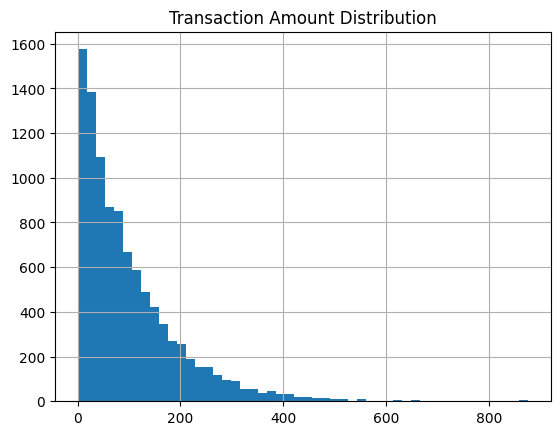

In [28]:
df['Transaction_Amount'].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

## Methodology

So the following steps were applied:
 1. Data preprocessing and feature encoding
 2. Train-test split
 3. Training multiple machine learning models
 4. Model evaluation using appropriate metrics
 5. Comparison of model performance

 And the following models were selected:
  - Logistic Regression as a baseline interpretable model
  - K-Nearest Neighbors as a distance-based method
  - Random Forest as an ensemble tree-based model
  - XGBoost as a gradient boosting algorithm

In [29]:
X = df.drop('Fraud_Label', axis=1)
y = df['Fraud_Label']

from sklearn.preprocessing import StandardScaler

numerical_cols = X.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)



In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)



In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', solver='liblinear')
lr.fit(X_train, y_train)




LogisticRegression(class_weight='balanced', solver='liblinear')

In [32]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight= y_train.value_counts()[0]/y_train.value_counts()[1])
xgb_model.fit(X_train, y_train)
y_prob = xgb_model.predict_proba(X_test)[:,1]




/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [01:14:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [33]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

## Model Evaluation

Models were evaluated using precision, recall, F1-score, and ROC-AUC. These metrics are suitable for imbalanced classification problems commonly found in financial fraud detection.

In [35]:
from sklearn.metrics import classification_report, roc_auc_score

models = [lr, knn, xgb_model, rf]
names = ['LogReg', 'KNN', 'XGBoost', 'Random Forest']

#Evaluation of all models
for model, name in zip(models, names):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))



LogReg
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1354
           1       0.66      0.74      0.70       646

    accuracy                           0.80      2000
   macro avg       0.77      0.78      0.77      2000
weighted avg       0.80      0.80      0.80      2000

ROC-AUC: 0.8957463495388048

KNN
              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1354
           1       0.78      0.58      0.66       646

    accuracy                           0.81      2000
   macro avg       0.80      0.75      0.76      2000
weighted avg       0.81      0.81      0.80      2000

ROC-AUC: 0.8813142803572491

XGBoost
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1354
           1       1.00      0.99      1.00       646

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2

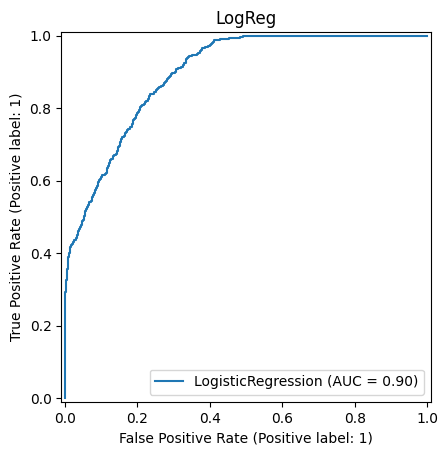

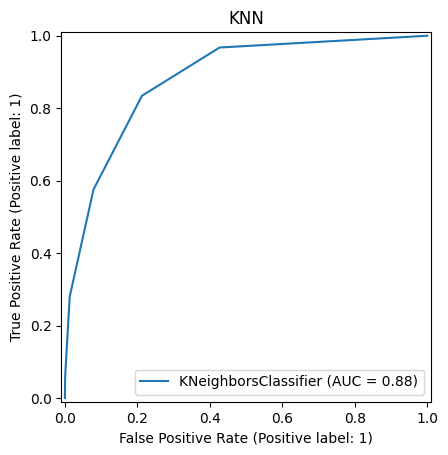

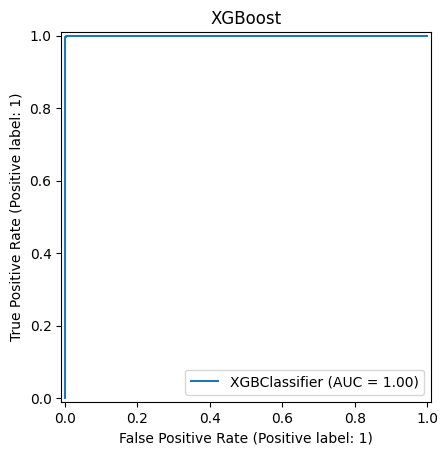

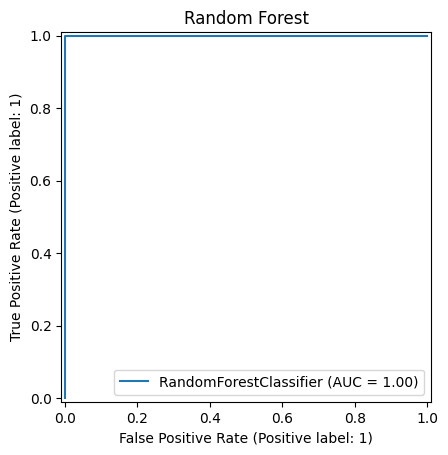

In [36]:
from sklearn.metrics import RocCurveDisplay

for model, name in zip(models, names):
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(name)
    plt.show()


## Results Discussion

Logistic Regression provides stable and interpretable results. KNN performs reasonably like well but is sensitive to data scaling. Tree-based ensemble models achieve near-perfect performance, which may indicate overfitting due to limited sample size.

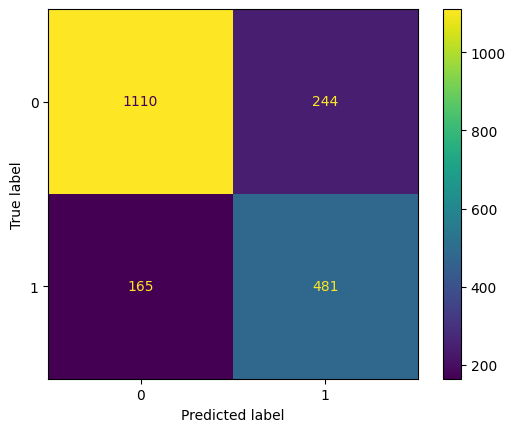

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.show()

## Feature Importance

I also make Analysis Feature Importance. It was performed for tree-based models to identify the most influential factors in fraud detection. Abd this is actually particularly important in financial applications where model interpretability matters.

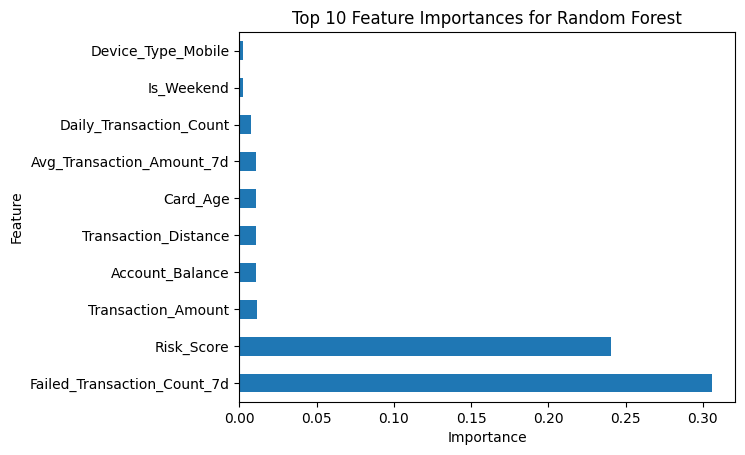

In [38]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances for Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


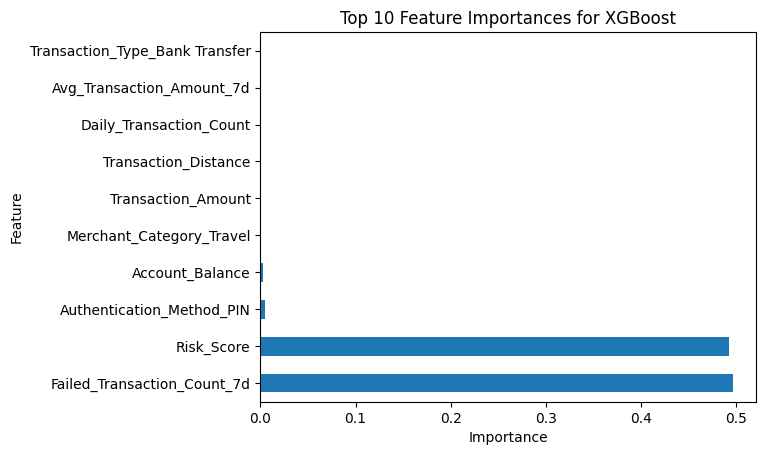

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

xgb_importance = xgb_model.feature_importances_
xgb_feat_imp = pd.Series(xgb_importance, index=X.columns).sort_values(ascending=False)

xgb_feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances for XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Limitations

Also, it's important to mentioned that the dataset size was reduced due to computational constraints. Additionally, near-perfect performance of ensemble models suggests potential overfitting, which should be addressed in real-world deployment using cross-validation and larger datasets.

## Conclusion

So, in this project, multiple machine learning models were applied to detect fraudulent financial transactions. And the results demonstrate that while complex models achieve high performance, simpler models such as Logistic Regression offer a good balance between performance and interpretability. Also this project highlights like the importance of proper evaluation metrics and model selection in financial machine learning tasks.